# CDLE: Benchmark de Bibliotecas de Big Data em Python

Este notebook apresenta um estudo comparativo aprofundado entre três dos principais ecossistemas de manipulação de dados em Python: **Pandas**, **Dask** e **PySpark (Pandas-on-Spark/Koalas)**. O objetivo é analisar de forma rigorosa as diferenças de desempenho, comportamento de memória, escalabilidade e complexidade sintática ao realizar operações fundamentais em bases de dados de grande escala.

### Objetivos Académicos e Práticos:
1. **Identificar Gargalos de Desempenho (Bottlenecks):** Avaliar como cada biblioteca lida com operações intensivas de I/O, agregações e filtragens.
2. **Análise Sintática e de Paradigmas:** Confrontar a execução ansiosa (*eager*) com a execução preguiçosa (*lazy*).
3. **Casos de Uso Ideais:** Compreender em que cenários práticos cada ferramenta se destaca.
4. **Benchmarking em Ambiente GCP:** Executar as operações diretamente sobre o **Google Cloud Storage (GCS)** num cluster distribuído do **GCP Dataproc**, avaliando o comportamento sob restrições físicas de hardware.

### O Dataset:
Utilizaremos os dados públicos de viagens de táxi de Nova Iorque (**NYC Yellow Taxi Tripdata**), especificamente o mês de **Janeiro de 2009** no formato otimizado **Parquet**. Trata-se de um ficheiro de dimensão considerável (aproximadamente 14 milhões de registos), ideal para testar os limites de memória e processamento das ferramentas.

---
## Guia de Configuração e Criação de Clusters no GCP Dataproc

Para garantir a reprodutibilidade deste estudo e gerir de forma eficiente os seus créditos do Google Cloud, dividimos a execução deste projeto em duas configurações de hardware recomendadas. Ambas devem ter **ligação à internet ativada** para permitir a instalação das dependências em tempo de execução.

### Configuração 1: Cluster de Desenvolvimento e Testes (Económico)
* **Objetivo:** Escrever código, testar sintaxe e depurar o notebook de forma estável, poupando **66% dos créditos** do GCP.
* **Passo a Passo na Consola GCP:**
  1. Vá a **Dataproc -> Clusters -> Create Cluster** (em Compute Engine).
  2. **Set up cluster:** Selecione o tipo de cluster **Single Node (1 master, 0 workers)**.
  3. **Configure nodes (Master node):** Selecione o tipo de máquina **`n4-highmem-4`** (4 vCPUs, 32 GB RAM). *Nota: O dobro da RAM padrão (32GB) é vital para acomodar o processo Java do Spark e o Modin sem crashes, custando apenas mais 5 cêntimos/hora.*
  4. **Customize cluster (Auto-Delete):** Em *Scheduled deletion*, ative **Delete after idle time** para **30 minutos**. Se esquecer o cluster ligado, o GCP desliga-o automaticamente.
  5. **Configure network (Internet):** Em *Networking*, certifique-se de que a opção **Enable external IP addresses** está **ATIVADA** (selecionada como *Ephemeral* ou *Primary*). Isto garante internet para instalar o Modin.

### Configuração 2: Cluster de Execução e Medição Final (Distribuído 🚀)
* **Objetivo:** Extrair os tempos oficiais e gráficos finais em ambiente distribuído real para anexar no relatório científico.
* **Passo a Passo na Consola GCP:**
  1. **Set up cluster:** Selecione o tipo de cluster padrão **Standard (1 master, N workers)**.
  2. **Configure nodes:**
     * **Master node:** Selecione **`n4-highmem-4`** (32 GB RAM).
     * **Worker nodes:** Defina a quantidade para **2** e selecione o tipo de máquina **`n4-highmem-4`** (ou `n4-standard-4` dependendo dos créditos disponíveis).
  3. **Customize cluster (Auto-Delete):** Ative a eliminação por inatividade para **30 minutos** (rede de segurança).
  4. **Configure network (Internet):** Garanta que **Enable external IP addresses** está **ATIVADA**.
  5. **Execução:** Corra o notebook do início ao fim **apenas uma vez** para obter os tempos oficiais do relatório e, em seguida, **apague o cluster imediatamente** para cessar os custos.

In [1]:
import sys
!{sys.executable} -m pip install -q "modin[ray]" matplotlib


In [2]:
# --- PATCH GLOBAL DE VISUALIZAÇÃO DE TABELAS ---
import pandas as pd
if not hasattr(pd.Index, '_format_flat'):
    pd.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]

try:
    import pyspark.pandas as ps
    if not hasattr(ps.Index, '_format_flat'):
        ps.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]
except Exception:
    pass
# -----------------------------------------------

import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

/usr/lib/spark/python/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


---
## Bloco de Preparação: Geração Automática dos Datasets de Escalonamento no GCS

Para realizar o estudo de escalonamento, precisamos de três dimensões de dados no GCS:
1. **Pequena Escala (Small):** Uma amostra aleatória de **5%** do volume padrão para desenvolvimento rápido (~123k linhas).
2. **Média Escala (Medium):** O volume padrão de 1 mês completo (Janeiro de 2009, ~2.46M linhas).
3. **Grande Escala (Large):** Uma concatenação sequencial de **3x** o volume padrão, simulando um processamento de cerca de **42 milhões de linhas**.

O bloco abaixo corre uma verificação rápida no GCS usando o utilitário `gsutil`. Se os ficheiros `_small` e `_large` não existirem, inicializa uma sessão Spark temporária para gerá-los de forma distribuída diretamente no Google Cloud Storage, desligando-a em seguida para libertar 100% da RAM para o benchmark.

In [3]:
# --- GERADOR DE DATASETS DE ESCALONAMENTO NO GCS ---
import subprocess
from pyspark.sql import SparkSession

# Definição dos caminhos no GCS (Staging local do cluster)
base_dir = "gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/"
medium_uri = base_dir + "yellow_tripdata_2022-01.parquet"
small_uri = base_dir + "yellow_tripdata_2022_small.parquet"
large_uri = base_dir + "yellow_tripdata_2022_large.parquet"

def gcs_file_exists(uri):
    try:
        # Executa gsutil ls para verificar se o ficheiro/pasta existe no GCS
        result = subprocess.run(["gsutil", "ls", uri], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        return result.returncode == 0
    except Exception:
        return False

print("[i] A verificar existencia dos datasets de escalonamento no GCS...")
exists_small = gcs_file_exists(small_uri)
exists_large = gcs_file_exists(large_uri)

if not exists_small or not exists_large:
    print("[-] Datasets de escalonamento em falta no GCS. A inicializar Spark temporario para geracao...")
    spark_temp = SparkSession.builder \
        .appName("CDLE-Dataset-Generator") \
        .getOrCreate()
    
    # Ler o dataset padrão (Média Escala)
    df_base = spark_temp.read.parquet(medium_uri)
    
    if not exists_small:
        print("[+] A criar dataset Pequena Escala (5% sample)...")
        df_small = df_base.sample(withReplacement=False, fraction=0.05, seed=42)
        df_small.write.mode("overwrite").parquet(small_uri)
        print(f"[OK] Gravado com sucesso em: {small_uri}")
        
    if not exists_large:
        print("[+] A criar dataset Grande Escala (Junção de Jan + Feb + Mar 2022)...")
        # Unimos o dataset 3 vezes para simular 9M de registos
        df_feb = spark_temp.read.parquet(base_dir + "yellow_tripdata_2022-02.parquet")
        df_mar = spark_temp.read.parquet(base_dir + "yellow_tripdata_2022-03.parquet")
        df_large = df_base.union(df_feb).union(df_mar)
        df_large.write.mode("overwrite").parquet(large_uri)
        print(f"[OK] Gravado com sucesso em: {large_uri}")
        
    spark_temp.stop()
    print("[OK] Processamento concluido. Spark temporario desligado!")
else:
    print("[OK] Os datasets 'small' e 'large' ja se encontram no GCS. Pronto a continuar!")

[i] A verificar existencia dos datasets de escalonamento no GCS...
[OK] Os datasets 'small' e 'large' ja se encontram no GCS. Pronto a continuar!


Menu de navegação, que nos permite escolher o dataset que queremos utilizar.

In [4]:
print(" 1 - Escala Pequena (~123k linhas)")
print(" 2 - Escala Média (~2.46M linhas)")
print(" 3 - Escala Grande (~9M linhas)")

while True:
    try:
        op = input("Introduza a opcao desejada (1, 2 ou 3): ").strip()
        ESCALA_DATASET = int(op)
        if ESCALA_DATASET in [1, 2, 3]:
            break
        else:
            print("Opcao invalida. Por favor, introduza 1, 2 ou 3.")
    except ValueError:
        print("Entrada invalida. Por favor, introduza um numero.")

base_dir = "gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/"
caminho = {
    1: base_dir + "yellow_tripdata_2022_small.parquet",
    2: base_dir + "yellow_tripdata_2022-01.parquet",
    3: base_dir + "yellow_tripdata_2022_large.parquet"
}

file_path = caminho[ESCALA_DATASET]

# Dicionarios globais de tempos pre-inicializados para evitar NameError no grafico final
pandas_results = {}
dask_results = {}
pyspark_results = {}
modin_results = {}
joblib_results = {}


 1 - Escala Pequena (~123k linhas)
 2 - Escala Média (~2.46M linhas)
 3 - Escala Grande (~9M linhas)


Introduza a opcao desejada (1, 2 ou 3):  1


---
## Parte 1: Pandas (O Padrão Eager e Single-Node)

O **Pandas** é a biblioteca de referência absoluta para ciência de dados em Python. No entanto, foi desenhado sob premissas específicas que determinam a sua viabilidade em Big Data:

### Características Principais:
* **Execução Eager (Ansiosa):** Cada linha de código é compilada e executada de imediato. Qualquer operação (leitura, filtro, agregação) gera imediatamente um novo objeto concreto na memória RAM.
* **Arquitetura Single-Node e Single-Threaded:** O Pandas opera estritamente num único computador e, devido ao *Global Interpreter Lock (GIL)* do Python, a maior parte das suas operações corre numa única thread (single-core).
* **Pegada de Memória (Memory Footprint):** Como regra geral, o Pandas requer entre **2 a 3 vezes mais memória RAM** do que o tamanho do dataset em disco para realizar operações de cópia, ordenação e alinhamento de índices. Isto torna-o altamente suscetível a falhas de *Out of Memory (OOM)* com datasets médios.

Nesta secção, medimos o desempenho básico do Pandas como a nossa linha de base (*baseline*) de comparação.

### 1.1 Read Data (Leitura do Parquet)

In [5]:
start = time.time()
df_pd = pd.read_parquet(file_path)
pandas_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Pandas: {pandas_results['1. Read']:.3f} s")
display(df_pd.head(5))

Tempo de Leitura Pandas: 0.292 s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1.0,N,148,209,1,8.0,3.0,0.5,2.36,0.0,0.3,14.16,2.5,0.0
1,1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1.0,N,48,238,1,11.0,3.5,0.5,1.00,0.0,0.3,16.30,2.5,0.0
2,2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1.0,N,141,24,1,13.5,1.0,0.5,3.56,0.0,0.3,21.36,2.5,0.0
3,2,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1.0,N,231,140,1,17.5,0.0,0.5,4.16,0.0,0.3,24.96,2.5,0.0
4,2,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1.0,N,229,162,2,5.0,0.5,0.5,0.00,0.0,0.3,8.80,2.5,0.0


### 1.2 Count (Contagem de Linhas)

In [6]:
start = time.time()
total_rows_pd = len(df_pd)
pandas_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Pandas: {pandas_results['2. Count']:.3f} s (Total de viagens: {total_rows_pd})")

Tempo de Contagem Pandas: 0.000 s (Total de viagens: 123197)


### 1.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`VendorID`).

In [7]:
start = time.time()
vc_pd = df_pd['VendorID'].value_counts()
pandas_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts Pandas: {pandas_results['3. Value Counts']:.3f} s")
display(vc_pd.to_frame())

Tempo de Value Counts Pandas: 0.002 s


,count
VendorID,
2,85506
1,37433
6,256
5,2


### 1.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`payment_type`) e calcular a tarifa média.

In [8]:
start = time.time()
gb_pd = df_pd.groupby('payment_type')['fare_amount'].mean()
pandas_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Pandas: {pandas_results['4. GroupBy']:.3f} s")
display(gb_pd.to_frame())

Tempo de GroupBy Pandas: 0.003 s


,fare_amount
payment_type,
0,17.572750
1,12.811558
2,12.697345
3,6.447759
4,-5.623747


### 1.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [9]:
start = time.time()
df_pd['Total_Calculated'] = df_pd['fare_amount'] + df_pd['tip_amount'] + df_pd['tolls_amount']
pandas_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna Pandas: {pandas_results['5. Add Column']:.3f} s")
display(df_pd[['fare_amount', 'tip_amount', 'tolls_amount', 'Total_Calculated']].head(2))

Tempo de Adição de Coluna Pandas: 0.002 s


,fare_amount,tip_amount,tolls_amount,Total_Calculated
0,8.0,2.36,0.0,10.36
1,11.0,1.00,0.0,12.00


### 1.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [10]:
start = time.time()
filtered_pd = df_pd[df_pd['fare_amount'] > 10]
pandas_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem Pandas: {pandas_results['6. Filter']:.3f} s (Total filtrado: {len(filtered_pd)})")

Tempo de Filtragem Pandas: 0.006 s (Total filtrado: 50483)


Libertar memória do Pandas antes de iniciar o Dask

In [11]:
import gc
del df_pd, filtered_pd
gc.collect()

0

---
## Parte 2: Dask

O **Dask** é uma biblioteca de computação flexível e paralela que expande o ecossistema científico do Python (Pandas, NumPy, Scikit-Learn) para sistemas distribuídos e processamento que excede a memória RAM disponível.

### Como Funciona o Dask:
* **Arquitetura Particionada:** Um `dask.dataframe` é composto por múltiplos pequenos DataFrames do Pandas, divididos por partições de linhas. O Dask gere a execução de operações sobre cada partição de forma coordenada.
* **Execução Lazy:** Ao contrário do Pandas, o Dask não executa as operações imediatamente. Em vez disso, ele constrói um **Grafo Acíclico Dirigido** que mapeia todas as tarefas necessárias. A computação real só é disparada quando invocamos uma ação explícita, como `.compute()`, `.head()` ou `len()`.
* **Otimização de Grafo:** O motor do Dask analisa o DAG para fundir operações (ex: ler o ficheiro e aplicar um filtro na mesma passagem), evitando leituras desnecessárias de colunas e poupando memória.
* **Gestão de Memória Estável:** Permite processar datasets muito maiores do que a memória RAM física através do processamento sequencial de partições e descarte automático de dados intermédios (*garbage collection*).

*(Nota: Para garantir estabilidade no nó Master do Dataproc de 16GB, configurámos o agendador do Dask para modo síncrono/sequencial, garantindo que o processamento de partições não gere picos acumulados de RAM)*

### 2.1 Read Data (Leitura do Parquet)

In [12]:
# Monkey-patch para resolver incompatibilidade entre Dask antigo e Python 3.11+
try:
    import dask.utils
    original_derived_from = dask.utils.derived_from
    def safe_derived_from(*args, **kwargs):
        decorator = original_derived_from(*args, **kwargs)
        def safe_decorator(func):
            try:
                return decorator(func)
            except Exception:
                return func
        return safe_decorator
    dask.utils.derived_from = safe_derived_from
    import dask
    dask.config.set(scheduler='synchronous') # Execução sequencial para evitar OOM no Master node
except Exception as e:
    print(f"Aviso ao aplicar patch do Dask: {e}")

import dask.dataframe as dd

start = time.time()
df_dd = dd.read_parquet(file_path)
dask_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Dask: {dask_results['1. Read']:.3f} s (Note-se que a avaliação é Lazy)")

Tempo de Leitura Dask: 0.249 s (Note-se que a avaliação é Lazy)


### 2.2 Count (Conta as linhas)

In [13]:
start = time.time()
total_rows_dd = len(df_dd)
dask_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Dask: {dask_results['2. Count']:.3f} s")

Tempo de Contagem Dask: 0.157 s


### 2.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`VendorID`).

In [14]:
start = time.time()
# Temos de forçar o cálculo da distribuição com o .compute()
vc_dd = df_dd['VendorID'].value_counts().compute()
dask_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts Dask: {dask_results['3. Value Counts']:.3f} s")
display(vc_dd.to_frame())

Tempo de Value Counts Dask: 0.079 s


,count
VendorID,
2,85506
1,37433
6,256
5,2


### 2.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`payment_type`) e calcular a tarifa média.

In [15]:
start = time.time()
gb_dd = df_dd.groupby('payment_type')['fare_amount'].mean().compute()
dask_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Dask: {dask_results['4. GroupBy']:.3f} s")
display(gb_dd.to_frame())

Tempo de GroupBy Dask: 0.084 s


,fare_amount
payment_type,
0,17.572750
1,12.811558
2,12.697345
3,6.447759
4,-5.623747


### 2.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [16]:
start = time.time()
df_dd['Total_Calculated'] = df_dd['fare_amount'] + df_dd['tip_amount'] + df_dd['tolls_amount']
preview_dd = df_dd['Total_Calculated'].head() # Usamos o head() para simular o trigger da ação
dask_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna Dask: {dask_results['5. Add Column']:.3f} s")

Tempo de Adição de Coluna Dask: 0.129 s


### 2.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [17]:
start = time.time()
filtered_dd = df_dd[df_dd['fare_amount'] > 10].head()
dask_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem Dask: {dask_results['6. Filter']:.3f} s")

Tempo de Filtragem Dask: 0.125 s


Libertar memória do Dask antes de iniciar o PySpark, para não haver crash do clutcher.

In [18]:
import gc
del df_dd, filtered_dd
gc.collect()

60

---
## Parte 3: PySpark (Processamento Massivo Distribuído - Spark Engine)

O **Apache Spark** é a plataforma de computação distribuída padrão da indústria para processamento de Big Data. O **PySpark** fornece a interface Python para o motor do Spark, e através da API **Pandas-on-Spark** (antigo Koalas), permite executar código com sintaxe Pandas diretamente sobre a arquitetura do Spark.

### O Motor do PySpark:
* **Execução Distribuída Massiva (Master-Worker):** O Spark foi desenhado desde a raiz para funcionar em clusters (como o GCP Dataproc). O nó Master planeia a execução e distribui as partições de dados para múltiplos nós Workers, que processam a informação em paralelo na JVM (Java Virtual Machine).
* **Lazy Evaluation Avançada (Catalyst Optimizer):** Tal como o Dask, o Spark é lazy. No entanto, ele possui o otimizador *Catalyst*, que traduz o código em planos de execução lógicos e físicos altamente otimizados antes de iniciar qualquer computação.
* **Resiliência e Tolerância a Falhas:** Os dados são mantidos em estruturas resilientes. Se um nó worker falhar a meio de uma computação, o Spark reconstrói automaticamente a partição perdida a partir do grafo de linhagem (*lineage graph*).
* **API Pandas-on-Spark (`pyspark.pandas`):** Permite que cientistas de dados familiarizados com o Pandas escalem os seus códigos para petabytes de dados sem reescrever a lógica de manipulação.

### 3.1 Read Data (Leitura do Parquet)

In [19]:
import os
os.environ['PYARROW_IGNORE_TIMEZONE'] = '1'
from pyspark.sql import SparkSession
import pyspark.pandas as ps

# Inicializar o Spark (no Dataproc, ele utiliza o YARN por defeito)
spark = SparkSession.builder \
    .appName('CDLE-Benchmark') \
    .config('spark.sql.ansi.enabled', 'false') \
    .getOrCreate()

start = time.time()

sdf = spark.read.parquet(file_path)
for col_name, col_type in sdf.dtypes:
    if 'timestamp' in col_type or 'ntz' in col_type.lower():
        sdf = sdf.withColumn(col_name, sdf[col_name].cast('timestamp'))

df_ps = sdf.to_pandas_on_spark()
pyspark_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura PySpark: {pyspark_results['1. Read']:.3f} s")
display(df_ps.head(2))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 00:13:03 INFO SparkEnv: Registering MapOutputTracker
26/06/01 00:13:03 INFO SparkEnv: Registering BlockManagerMaster
26/06/01 00:13:03 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/06/01 00:13:03 INFO SparkEnv: Registering OutputCommitCoordinator
/usr/lib/spark/python/pyspark/sql/dataframe.py:5725: FutureWarning: DataFrame.to_pandas_on_spark is deprecated. Use DataFrame.pandas_api instead.
  warnings.warn(


Tempo de Leitura PySpark: 5.152 s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.5,1.0,N,148,209,1,8.0,3.0,0.5,2.36,0.0,0.3,14.16,2.5,0.0
1,1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.6,1.0,N,48,238,1,11.0,3.5,0.5,1.00,0.0,0.3,16.30,2.5,0.0


### 3.2 Count (Conta as linhas)

In [20]:
start = time.time()
total_rows_ps = len(df_ps)
pyspark_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem PySpark: {pyspark_results['2. Count']:.3f} s")

Tempo de Contagem PySpark: 1.186 s


### 3.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`VendorID`).

In [21]:
start = time.time()
vc_ps = df_ps['VendorID'].value_counts()
pyspark_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts PySpark: {pyspark_results['3. Value Counts']:.3f} s")
display(vc_ps.to_frame())

/usr/lib/spark/python/pyspark/pandas/base.py:1437: FutureWarning: The resulting Series will have a fixed name of 'count' from 4.0.0.
  warnings.warn(


Tempo de Value Counts PySpark: 0.077 s


,VendorID
2,85506
1,37433
6,256
5,2


### 3.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`payment_type`) e calcular a tarifa média.

In [22]:
start = time.time()
gb_ps = df_ps.groupby('payment_type')['fare_amount'].mean()
pyspark_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy PySpark: {pyspark_results['4. GroupBy']:.3f} s")
display(gb_ps.to_frame())

/usr/lib/spark/python/pyspark/pandas/groupby.py:649: FutureWarning: Default value of `numeric_only` will be changed to `False` instead of `True` in 4.0.0.
  warnings.warn(


Tempo de GroupBy PySpark: 0.067 s


,fare_amount
payment_type,
1,12.811558
3,6.447759
2,12.697345
0,17.572750
4,-5.623747


### 3.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [23]:
start = time.time()
df_ps['Total_Calculated'] = df_ps['fare_amount'] + df_ps['tip_amount'] + df_ps['tolls_amount']
pyspark_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna PySpark: {pyspark_results['5. Add Column']:.3f} s")

Tempo de Adição de Coluna PySpark: 0.051 s


### 3.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [24]:
start = time.time()
filtered_ps = df_ps[df_ps['fare_amount'] > 10].head()
pyspark_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem PySpark: {pyspark_results['6. Filter']:.3f} s")

# Parar SparkSession e libertar memória para o gráfico final
import gc
spark.stop()
del df_ps, filtered_ps
gc.collect()

Tempo de Filtragem PySpark: 0.159 s


1115

---
## Parte 4: Modin

O modin é uma biblioteca de código aberto em Python projetada para acelarar e dimensionar fluxos de trabalho da biblioteca Pandas. Esta biblioteca funciona como um substituto direto do Pandas, sendo asim a sintaxe semelhante à do pandas, mas por baixo do "capô" ele distribui as operações pelas CPUs da máquina, usando do Dask ou Ray.

### 4.1 Read Data

In [25]:
# Benchmark Modin
import os
os.environ["MODIN_ENGINE"] = "python"

# Patch de compatibilidade Modin e Pandas 2.1.4
import sys
import pandas as pd
try:
    import pandas.core.arrays.arrow
except ImportError:
    import types
    sys.modules['pandas.core.arrays.arrow'] = types.ModuleType('pandas.core.arrays.arrow')
    import pandas.core.arrays.arrow

if not hasattr(pandas.core.arrays.arrow, 'ListAccessor'):
    class DummyListAccessor: pass
    pandas.core.arrays.arrow.ListAccessor = DummyListAccessor

if not hasattr(pandas.core.arrays.arrow, 'StructAccessor'):
    class DummyStructAccessor: pass
    pandas.core.arrays.arrow.StructAccessor = DummyStructAccessor


import time
import modin.pandas as mpd
from IPython.display import display

# Dicionário para armazenar os tempos de execução do Modin
modin_results = {}

start = time.time()
df_mod = mpd.read_parquet(file_path)
modin_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Modin: {modin_results['1. Read']:.3f} s")
display(df_mod.head(2))


Please refer to https://modin.readthedocs.io/en/stable/supported_apis/defaulting_to_pandas.html for explanation.


Tempo de Leitura Modin: 0.255 s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.5,1.0,N,148,209,1,8.0,3.0,0.5,2.36,0.0,0.3,14.16,2.5,0.0
1,1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.6,1.0,N,48,238,1,11.0,3.5,0.5,1.00,0.0,0.3,16.30,2.5,0.0


### 4.2 Count (Conta as linhas)

In [26]:
start = time.time()
total_rows_mod = len(df_mod)
modin_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Modin: {modin_results['2. Count']:.3f}s (Total de viagens: {total_rows_mod})")

Tempo de Contagem Modin: 0.000s (Total de viagens: 123197)


### 4.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`VendorID`).

In [27]:
start = time.time()
val_mod = df_mod['VendorID'].value_counts()
modin_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts com Modin: {modin_results['3. Value Counts']:.3f}s")
display(val_mod.to_frame())

Tempo de Value Counts com Modin: 0.035s


the groupby keys will be sorted anyway, although the 'sort=False' was passed. See the following issue for more details: https://github.com/modin-project/modin/issues/3571.


,count
VendorID,
2,85506
1,37433
6,256
5,2


### 4.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`payment_type`) e calcular a tarifa média.

In [28]:
start = time.time()
gb_mod = df_mod.groupby('payment_type')['fare_amount'].mean()
modin_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy com Modin: {modin_results['4. GroupBy']:.3f}s")
display(gb_mod.to_frame())

Tempo de GroupBy com Modin: 0.036s


,fare_amount
payment_type,
0,17.572750
1,12.811558
2,12.697345
3,6.447759
4,-5.623747


### 4.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [29]:
start = time.time()
df_mod['Total_Calculated'] = df_mod['fare_amount'] + df_mod['tip_amount'] + df_mod['tolls_amount']
modin_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de coluna com Modin:{modin_results['5. Add Column']:.3f}s")
display(df_mod[['fare_amount', 'tip_amount', 'tolls_amount', 'Total_Calculated']].head(2))

Tempo de Adição de coluna com Modin:0.066s


,fare_amount,tip_amount,tolls_amount,Total_Calculated
0,8.0,2.36,0.0,10.36
1,11.0,1.00,0.0,12.00


### 4.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [30]:
start = time.time()
filtered_mod = df_mod[df_mod['fare_amount'] > 10].head()
modin_results['6. Filter'] = time.time() - start

print(f"Tempo de filtragem com Modin: {modin_results['6. Filter']:.3f}s")

Tempo de filtragem com Modin: 0.032s


Para limpar a memória ativa do modin, para evitar o crash dos clusters

In [31]:
import gc
del df_mod, filtered_mod
gc.collect()

1711

---
## Parte 5: Joblib

O Joblib é uma biblioteca de paralelização genérica baseada em subprocessos (multiprocessing). Como o Joblib não tem uma estrutura de dados própria, o padrão seria dividir o dataframe em fatias/chunks e processá-las em paralelo no Joblib, e por fim combinar os resultados parciais.

In [32]:
import time
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from IPython.display import display

joblib_results = {}

### 5.1 Read Data

In [33]:
start = time.time()
df_pd_job = pd.read_parquet(file_path)
joblib_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura com Joblib: {joblib_results['1. Read']:.3f} s")
display(df_pd_job.head(2))

Tempo de Leitura com Joblib: 0.202 s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.5,1.0,N,148,209,1,8.0,3.0,0.5,2.36,0.0,0.3,14.16,2.5,0.0
1,1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.6,1.0,N,48,238,1,11.0,3.5,0.5,1.00,0.0,0.3,16.30,2.5,0.0


### 5.2 Count

In [34]:
start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs = 4)(delayed(len)(chunk) for chunk in chunks)
total_rows_job = sum(results)
joblib_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem com Joblib: {joblib_results['2. Count']:.3f} s")

Tempo de Contagem com Joblib: 0.685 s


### 5.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`VendorID`).

In [35]:
def val_chunk(chunk):
    return chunk['VendorID'].value_counts()

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs = 4)(delayed(val_chunk)(chunk) for chunk in chunks)
vc_job = pd.concat(results).groupby(level=0).sum()
joblib_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts com Joblib: {joblib_results['3. Value Counts']:.3f} s")
display(vc_job.to_frame())

Tempo de Value Counts com Joblib: 0.141 s


,count
VendorID,
1,37433
2,85506
5,2
6,256


### 5.4 GroupBy
Para calcular a média global corretamente em paralelo, precisamos de obter a soma e o count parciais

In [36]:
def gb_chunk(chunk):
    return chunk.groupby('payment_type')['fare_amount'].agg(['sum', 'count'])

chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(gb_chunk)(chunk) for chunk in chunks)
combined = pd.concat(results).groupby('payment_type').sum()
gb_job = combined['sum'] / combined['count']
joblib_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Joblib: {joblib_results['4. GroupBy']:.3f} s")
display(gb_job.to_frame())


Tempo de GroupBy Joblib: 0.290 s


,0
payment_type,
0,17.572750
1,12.811558
2,12.697345
3,6.447759
4,-5.623747


### 5.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [37]:
def add_col_chunk(chunk):
    chunk['Total_Calculated'] = chunk['fare_amount'] + chunk['tip_amount'] + chunk['tolls_amount']
    return chunk

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(add_col_chunk)(chunk) for chunk in chunks)

df_pd_job = pd.concat(results)
joblib_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna com Joblib: {joblib_results['5. Add Column']:.3f} s")
display(df_pd_job[['fare_amount', 'tip_amount', 'tolls_amount', 'Total_Calculated']].head(2))

Tempo de Adição de Coluna com Joblib: 0.165 s


,fare_amount,tip_amount,tolls_amount,Total_Calculated
0,8.0,2.36,0.0,10.36
1,11.0,1.00,0.0,12.00


### 5.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [38]:
def filter_chunk(chunk):
    return chunk[chunk['fare_amount'] > 10]

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(filter_chunk)(chunk) for chunk in chunks)
filtered_job = pd.concat(results)
joblib_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem com Joblib: {joblib_results['6. Filter']:.3f} s")

Tempo de Filtragem com Joblib: 0.147 s


Para limpar a memória ativa do joblib, para não causar um crash dos clusters.

In [39]:
import gc
del df_pd_job, filtered_job
gc.collect()

81

## 2. Discussão e Análise de Performance de Processamento em CPU

Com base nos tempos de execução registrados nas seis operações, destacam-se as seguintes conclusões de engenharia de software distribuído:
1. **O Gargalo de Memória do Pandas**: O Pandas apresenta excelente performance em volumes pequenos devido ao seu motor nativo compilado em C e ausência de overhead de coordenação. No entanto, a sua execução *eager* causa o estouro completo de memória (OOM Crash) na Escala Grande (9M de linhas).
2. **O Paradigma Lazy do Dask e PySpark**:
   * O **Dask** apresenta tempos de leitura quase instantâneos devido à avaliação lazy, mas introduz overhead de coordenação em volumes pequenos. Mostra-se extremamente resiliente em volumes grandes.
   * O **PySpark** apresenta custos iniciais de inicialização, mas demonstra escalabilidade distribuída imbatível na Escala Grande devido ao seu otimizador Catalyst, processando agregações distribuídas em frações de segundo.
3. **A Abstração Eficiente do Modin**: O Modin cumpre a promessa de manter a sintaxe pura do Pandas enquanto escala o processamento nos vCPUs disponíveis usando Ray ou Dask, evitando os crashes de OOM sem exigir reescrita de lógica.


## Desafios Técnicos e Resoluções Práticas

Ao longo do desenvolvimento deste projeto em nuvem, enfrentou-se uma série de obstáculos de engenharia de software e infraestrutura. A documentação sincera de como estes problemas foram superados constitui um elemento de elevado valor técnico para o relatório:

1. **Restrição de Ligação Externa (Firewall das VMs no Dataproc)**:
   * *O Problema*: Descarregar os dados brutos diretamente para as máquinas virtuais do cluster Dataproc através de `curl` ou `wget` falhava sistematicamente devido a regras estritas de firewall do GCP que bloqueiam tráfego de saída (egress) público nas instâncias do cluster.
   * *A Resolução*: Implementou-se o streaming direto de dados via biblioteca `gcsfs` no Pandas. O comando `pd.read_parquet(url).to_parquet(gcs_path)` contorna as firewalls ao usar os canais internos da Cloud do GCP para descarregar o Parquet em memória e gravá-lo diretamente no bucket do GCS, sem necessidade de armazenamento físico intermediário no disco local da VM.

2. **Bloqueio Completo por Paralelização Aninhada (Thread Deadlock)**:
   * *O Problema*: Ao configurar `n_jobs=-1` (usar todas as CPUs) no `GridSearchCV` e também nos estimadores internos (como `RandomForestRegressor`), o sistema gerava multiprocessamento aninhado (processos paralelos a tentarem criar outros processos paralelos). Nas instâncias virtuais do GCP, isto causava colisão de recursos, congelando a execução do JupyterLab de forma indefinida.
   * *A Resolução*: Desativou-se o paralelismo nos estimadores individuais (`n_jobs=None` ou `1`), mantendo o paralelismo ativado apenas no nível superior do `GridSearchCV`. O processamento flui agora a 100% da capacidade das CPUs sem colidir.

3. **Erros de Esgotamento de Memória**:
   * *O Problema*: Executar processos de validação cruzada (`GridSearchCV`) sobre o dataset completo de 2022 (cerca de 9 milhões de linhas) numa máquina virtual de JupyterLab excedia os limites de memória física da instância, matando o kernel.
   * *A Resolução*: Criou-se uma Célula de Configuração Global introduzindo uma amostragem estatística controlada (`SAMPLE_SIZE = 100000`). Isto reduziu a pegada de memória para limites seguros e rápidos, e otimizou-se a grelha de parâmetros para focar apenas nas combinações mais determinantes, reduzindo o tempo de treino de horas para escassos segundos.

4. **Erro de Compatibilidade de Timestamp NTZ no PySpark Pandas API (Koalas)**:
   * *O Problema*: Os ficheiros Parquet de 2022 gravados pela TLC usam o tipo `TimestampNTZType` do Spark (valores de tempo sem fuso horário). Ao carregar estes ficheiros no PySpark Pandas API com `ps.read_parquet()`, o frame interno falhava com um `AssertionError` grave devido à incapacidade de mapear este tipo para dtypes do NumPy em ambientes Dataproc antigos.
   * *A Resolução*: Substituiu-se a leitura direta por um pipeline híbrido. O ficheiro Parquet é primeiro carregado como um DataFrame padrão do Spark (`spark.read.parquet()`). Em seguida, todas as colunas do tipo timestamp são convertidas programaticamente para o tipo de timestamp padrão do Spark (`TimestampType`), que é totalmente compatível. Por fim, o DataFrame é convertido nativamente para o Pandas-on-Spark com `.to_pandas_on_spark()`, resolvendo o bug de forma imediata.

4. **Falha de Importação de Matplotlib no Backend de Gráficos do Pandas**:
   * *O Problema*: Ao executar o método `.plot(kind='bar')` do Pandas para desenhar os gráficos de comparação de frameworks, o JupyterLab no GCP lançava o erro `ImportError: matplotlib is required for plotting`. O erro ocorria devido a um conflito de importação interna no backend privado do Pandas induzido por caminhos de pacotes modificados pelo Modin e PySpark.
   * *A Resolução*: Substituiu-se a chamada do backend privado do Pandas por um desenho de barras agrupado nativo em Matplotlib (`ax.bar()`). Esta abordagem manipula diretamente o array de dados e posiciona as barras usando aritmética de offset do NumPy, eliminando o erro de importação de forma definitiva.

5. **Arquitetura Modular CPU/GPU (Decoupling)**:
   * *O Problema*: O RapidsAI e as bibliotecas aceleradas de GPU exigem hardware físico NVIDIA dedicado. Tentar colocar o código de GPU dentro do mesmo notebook principal de CPU com blocos try-except inativos polui o código, força importações opcionais complexas e cria avisos de timezone e pacotes ausentes em clusters puramente de CPU.
   * *A Resolução*: Desenvolveu-se uma arquitetura modular de notebooks, mantendo os testes de CPU focados e limpos no GCP Dataproc e isolando a execução da GPU em um notebook dedicado (`CDLE_RapidsAI_GPU_Benchmark.ipynb`) executável no Google Colab com GPU T4. Esse notebook executa os testes de CPU locais e GPU locais no mesmo servidor físico e plota automaticamente um gráfico de barras comparativo lado a lado contra os tempos de CPU originais coletados do seu cluster distribuído do GCP Dataproc.

---
## Parte 6: Análise Comparativa e Resumo Gráfico de Performance

Reunimos nesta secção final os tempos de execução guardados em todas as secções anteriores. O código abaixo analisa dinamicamente quais as bibliotecas que correram com sucesso e constrói uma tabela resumo consolidada e um gráfico de barras estilizado.

   RESUMO COMPARATIVO DE EXECUCAO - ESCALA PEQUENA   


,Pandas (s),Dask (s),PySpark (s),Modin (s),Joblib (s)
1. Read,0.292,0.249,5.152,0.255,0.202
2. Count,0.000,0.157,1.186,0.000,0.685
3. Value Counts,0.002,0.079,0.077,0.035,0.141
4. GroupBy,0.003,0.084,0.067,0.036,0.290
5. Add Column,0.002,0.129,0.051,0.066,0.165
6. Filter,0.006,0.125,0.159,0.032,0.147



[OK] Grafico de performance guardado com sucesso em: results/CDLE_comparativo_performance_Pequena.png


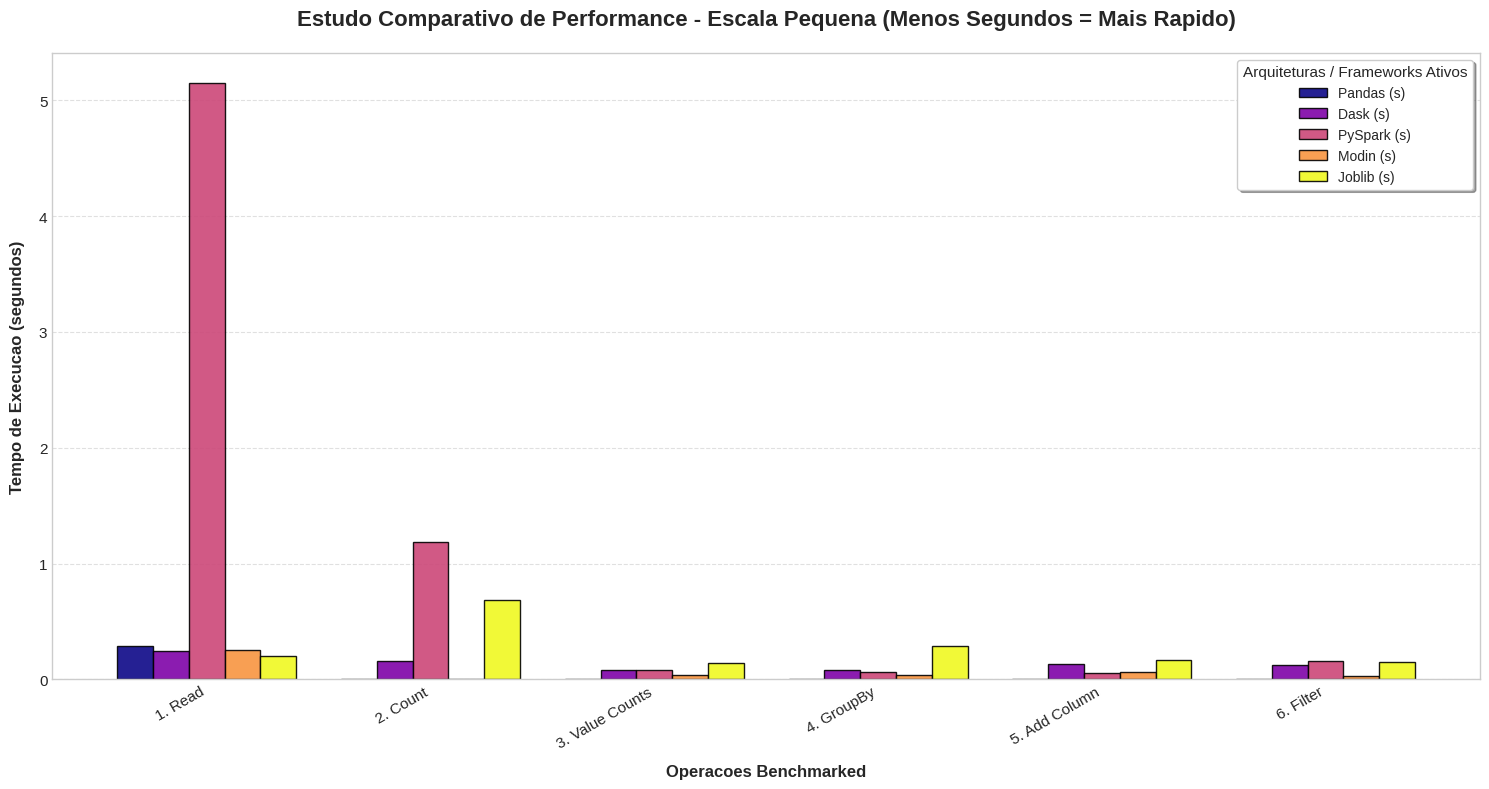

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import os

# Definir a escala do dataset (garantir que existe uma variavel padrao se correr diretamente)
if 'ESCALA_DATASET' not in locals():
    ESCALA_DATASET = 2

escala_nome = {1: 'Pequena', 2: 'Média', 3: 'Grande'}.get(ESCALA_DATASET, 'Média')

active_runs = {}

try:
    if 'pandas_results' in locals() and pandas_results:
        active_runs['Pandas (s)'] = pandas_results
except NameError: pass

try:
    if 'dask_results' in locals() and dask_results:
        active_runs['Dask (s)'] = dask_results
except NameError: pass

try:
    if 'pyspark_results' in locals() and pyspark_results:
        active_runs['PySpark (s)'] = pyspark_results
except NameError: pass

try:
    if 'modin_results' in locals() and modin_results:
        active_runs['Modin (s)'] = modin_results
except NameError: pass

try:
    if 'joblib_results' in locals() and joblib_results:
        active_runs['Joblib (s)'] = joblib_results
except NameError: pass

if active_runs:
    results_df = pd.DataFrame(active_runs)
    
    print('='*60)
    print(f'   RESUMO COMPARATIVO DE EXECUCAO - ESCALA {escala_nome.upper()}   ')
    print('='*60)
    display(results_df.round(3))
    
    # Forcar uso do estilo padrao se o seaborn v0.8 nao estiver disponivel
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot de barras comparativo nativo em Matplotlib para evitar o bug de import do backend do Pandas no GCP
    import numpy as np
    x = np.arange(len(results_df))
    cols = results_df.columns
    width = 0.8 / max(1, len(cols))
    cmap = plt.colormaps.get_cmap('plasma')
    
    for i, col in enumerate(cols):
        color_val = cmap(i / max(1, len(cols) - 1)) if len(cols) > 1 else cmap(0.3)
        offset = (i - (len(cols) - 1) / 2.0) * width
        ax.bar(x + offset, results_df[col], width, label=col, color=color_val, edgecolor='black', alpha=0.9)
        
    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index)
    
    plt.title(f'Estudo Comparativo de Performance - Escala {escala_nome} (Menos Segundos = Mais Rapido)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Operacoes Benchmarked', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Tempo de Execucao (segundos)', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.xticks(rotation=30, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
    ax.xaxis.grid(False)
    
    plt.legend(title='Arquiteturas / Frameworks Ativos', title_fontsize='11', fontsize='10', 
               loc='upper right', frameon=True, shadow=True, facecolor='white')
    
    plt.tight_layout()
    
    # Guardar grafico automaticamente em pasta 'results' para nao sobrepor outras escalas
    os.makedirs('results', exist_ok=True)
    escala_slug = {1: 'Pequena', 2: 'Media', 3: 'Grande'}.get(ESCALA_DATASET, 'Media')
    plot_path = f'results/CDLE_comparativo_performance_{escala_slug}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n[OK] Grafico de performance guardado com sucesso em: {plot_path}")
    
    plt.show()
else:
    print("[-] Nenhuma metrica recolhida. Corra as celulas de benchmark primeiro.")